## Oppgave 3


##### Viktige funksjoner for å kjøre senere kode:

In [7]:
import scipy as sp
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

"""Antatte start parametere"""
#modifiseres i oppgavene der relevant
alpha = 0.8
T = 273.15 + 37
beta = (sp.constants.Boltzmann *T)**-1
N_x = 100
periods = 2
N_points = periods*N_x
N_particles = 12*N_x
k = 1000/beta

T_p = 500
h = 1

"""Sannsynlighets utrykk"""
def p_plus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0 + 1))) + np.exp(-beta*(V(x_0) - V(x_0 + 1)))
    return 1/denonimator

def p_zero(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0))) + np.exp(-beta*(V(x_0 + 1) - V(x_0)))
    return 1/denonimator

def p_minus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
    return 1/denonimator

"""Potensial funksjoner"""
def V_1_vectorized(x):
    #normaliserer x til periodisiteten
    V_1 = np.zeros(np.shape(x))

    L = -(1-alpha)*N_x
    positions = L + (x-L)%N_x

    #returnerer potensialet i punkt
    V_1 += (positions > 0) * positions*k / (alpha*N_x)
    V_1 += -1*(positions <= 0)*positions*k/ ((1-alpha)*N_x)
    
    return V_1
    

def V_2(x):
    return k


"""Simulerings funkjoner"""

def random_walk_system_vectorized(particles, positions, potential):
    """
        Funksjon som tar alle partiklene fram ett tissteg
        returnerer nye posisjoner og snitt strøm for tidssteget
    """

    movements = np.random.uniform(size=N_particles)
    particle_probs = np.array((p_minus(positions[particles], beta, potential), p_plus(positions[particles], beta, potential)))

    move_left = np.less_equal(movements, particle_probs[0])*1
    move_right = np.greater_equal(movements, 1 - particle_probs[1])*1
    n_plus = np.sum(move_right)
    n_minus = np.sum(move_left)

    particles += move_right - move_left

    
    particles -= np.equal(particles, N_points)*N_points
    particles += np.equal(particles, -1)*N_points

    particles = np.where(particles == 200, 0, particles)
    particles = np.where(particles == -1, periods * N_x - 1, particles)

    return particles, (n_plus-n_minus) / N_particles
    


def random_walk_cycle_vectorized(positions,particles):
    """
        Funkjon som tar hele systemt en syklus (2 T_p tidssteg)

        returnerer posisjonene etter syklusen og snitt strømmen for syklusen
    """

    avg_stream = 0
    
    #går alle tidsstegene
    for timestep in range(2*T_p):
        
        #antar V1 med mindre vi er i en oddetalls del av syklusen
        V = V_2
        if timestep > T_p:
            V = V_1_vectorized

        
        #lagerer strømmene
        particles, stream = random_walk_system_vectorized(particles, positions, V)
        avg_stream += stream

    avg_stream /= 2*T_p

    return particles, avg_stream

"""Analytiske utrykk"""

def analytical_avg_current(a, Tp):
    """
        Analytisk strømning som funkjon av alpha og T_p
    """

    multiplier = N_x/2 * np.sqrt(3/Tp)
    erfc_left = sp.special.erfc(a*multiplier)
    erfc_right = sp.special.erfc((1-a)*multiplier)

    return N_x/(4*Tp) * (erfc_left - erfc_right)


#### Oppgave start:

#### a)

In [8]:
def oppgave_3_a(num_cycles = 10):

    """
        Initialiserer parameterene og printer for hver syklus for oppgave 3a
    """
    global N_x
    N_x = 100
    
    global N_particles
    N_particles = 12*N_x

    global alpha
    alpha = 0.8

    global T_p
    T_p = 500

    #Initialliserer partikellene jevnt utover 
    particles = np.array((np.arange(0, N_points, 1, dtype=np.int16),))
    one = np.ones((int(N_particles/N_points),1), dtype = np.int16)
    particles = np.ndarray.flatten(one @ particles)

    positions = np.linspace(0, h*N_points-1, N_points)
    streams = np.zeros(num_cycles)

    #Kjører systemet én syklus og printer snitt strømmen
    for cycle in range(num_cycles):
        particles, streams[cycle] = random_walk_cycle_vectorized(positions, particles)
        print(f"cycle: {cycle}, average stream {streams[cycle]}")

   
oppgave_3_a()

cycle: 0, average stream -0.029750000000000002
cycle: 1, average stream -0.011166666666666665
cycle: 2, average stream -0.011916666666666664
cycle: 3, average stream -0.011583333333333334
cycle: 4, average stream -0.012916666666666667
cycle: 5, average stream -0.013416666666666667
cycle: 6, average stream -0.013083333333333337
cycle: 7, average stream -0.011916666666666674
cycle: 8, average stream -0.011499166666666664
cycle: 9, average stream -0.013084166666666671



Netto strømning blir større enn null ettersom vi ikke har ren diffusjon. Når potensialet er konstant, er sannsynlighetene for bevegelse i positiv og negativ retning like. Dermed blir netto strømning null. Når sagtannpotensialet er aktivt derimot blir $p^+ {\not =} p^-$ for alle bindingspunkter (utenom tilfellet der $\alpha = 0.5$). Og partiklene der vil tendere mot en retning. Hvilken retning en partikkel på et gitt bindingspunkt tenderer mot vil avhenge av $\alpha$.

Bare i tilfellet der sagtann potensialet er symmetrisk om toppunktet ($\alpha = 0.5$) vil strømningen være 0 ettersom begge potensialene er symmetriske.

Vi ser en større strøm i den første syklusen enn vi gjør i de senere (ca dobbelt så stor). Dette kommer av at når denne syklusen starter er alle proteinene fordelt jevn over rommet. Under starten av senere sykler derimot vil proteinene alle være bundet i en brønn i sagtann potensialet. Når de diffunderer herfra kommer færre til å forflytte seg over neste potensialtopp før sagtannpotensialet blir gjeldene.


#### b)

100%|██████████| 50/50 [00:04<00:00, 10.13it/s]


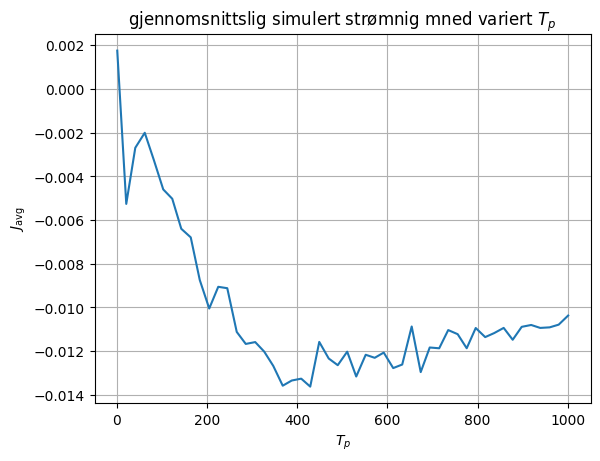

In [10]:
def oppgave_3_b(num_values = 50):
    """
        Initialiserer parameterene og plotter gjennomsnitslig strømning per syklus mot T_p
    """

    global N_particles
    N_particles = 4*N_x

    global alpha
    alpha = 0.8

    #initialliserer partiklene i bunnpunkt for sagtann poteniale
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    

    global T_p
    Tp_range = np.linspace(1, 1001, num_values, dtype=np.int16) 

    # itererer over tids steg lengdene flere ganger og tar gjennomsnitt for å få mindre støy i data
    for _ in range(5):
        for i,T in enumerate(tqdm(Tp_range)):
            T_p = T
            particles = np.copy(particles_start)
            _, s = random_walk_cycle_vectorized(positions, particles)
            streams[i] += s
    streams /= 5

    #plotter
    plt.plot(Tp_range, streams)
    plt.grid()
    plt.title(f"gjennomsnittslig simulert strømnig mned variert $T_p$")
    plt.xlabel(f"$T_p$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.show()

oppgave_3_b()

Strømningen øker mot venstre med økt $T_p$ i intervallet cirka $[1,500]$, etter dette minker strømningen sakte. Økningen i strømning mot venstre i det første intervallet skyldes nok at proteinene får mer tid til å diffundere, hvilket gjør at fler av dem kan stige over i neste konvekse del av potensialet. Nedgangen for $T_p > \sim 500$ skyldes nok dermed at vi når et punkt der proteinene er nært uniformt fordelt. Dermed vil påfølgende tissteg ikke bidra til å øke strømningen ved potensialbytte. Proteinene vil også bruke mer tid "fanget" i potenisalbrønnene. Dermed øker ikke netto strømning. Og ettersom $J_\text{avg} \propto \frac 1 T_p $ bidrar dette til at $J_\text{avg}$ synker.

#### c)

  0%|          | 0/50 [00:00<?, ?it/s]C:\Users\theod\AppData\Local\Temp\ipykernel_18856\3529697032.py:22: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0 + 1))) + np.exp(-beta*(V(x_0) - V(x_0 + 1)))
 96%|█████████▌| 48/50 [00:08<00:00,  5.96it/s]C:\Users\theod\AppData\Local\Temp\ipykernel_18856\3529697032.py:30: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
100%|██████████| 50/50 [00:08<00:00,  5.93it/s]


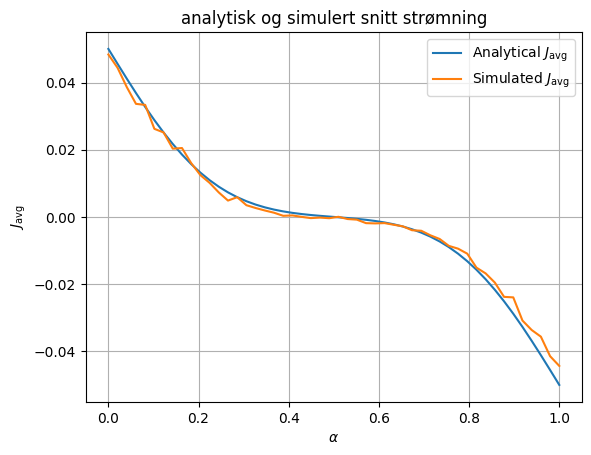

In [11]:

def oppgave_3_c(num_values = 50):
    """
        Initialiserer parameterene, Plotter gjennomsnitslig strømning per syklus mot alpha og det analytiske utrykket for gjennomsnitslig strømning sfa alpha
    """

    global T_p
    T_p = 500
    global N_particles
    N_particles = 12*N_x
    
    #initialiserer i potenial brønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x

    
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    i = 0

    global alpha
    alpha_range = np.linspace(1e-5,1-1e-5,num_values) #Velger små verdier som approximerer de egentlige grensene for å unngå overflow 

    # itererer over alpha verider
    for a in tqdm(alpha_range):
        alpha = a
        particles = np.copy(particles_start)
        _, streams[i] = random_walk_cycle_vectorized(positions, particles)
        i+=1

    #plotter
    plt.plot(alpha_range, analytical_avg_current(alpha_range, T_p,), label=r"Analytical $J_\text{avg}$")
    plt.plot(alpha_range, streams, label=r"Simulated $J_\text{avg}$")
    plt.legend()
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.title("analytisk og simulert snitt strømning")
    plt.grid()
    plt.show()
    
oppgave_3_c()

Den simulerte strømningen passer godt med den analytiske. Vi ser at for små $\alpha$ er $J_\text{avg} > 0$ altså går netto strømningen mot høyre. Og for store $\alpha$ går strømmen mot venstre. Som nevnt i a) er strømningen 0 for $\alpha \approx 0.5$.  Når $\alpha$ er liten er majoriteten av hver "sagtann" til høyre for toppen hvilket gir økt sannsynlighet for steg til høyre. Samme logikk forklarer strømning i negativ retning for $\alpha > 0.5$. Dermed passer den analytiske løsningen det vi forventer gitt sannsynlighets funksjonene.

#### d)

100%|██████████| 6/6 [00:49<00:00,  8.31s/it]


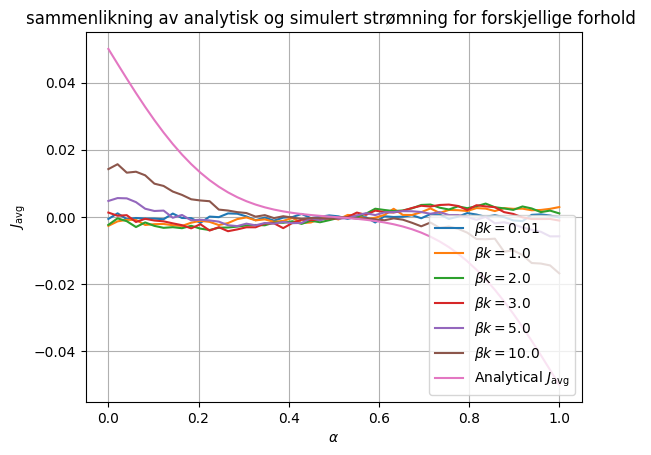

In [12]:
def oppgave_3_d(num_values = 50):
    """
        Initialiserer parameterene, Plotter gjennomsnitslig strømning per syklus mot alpha for gitte verdier av k*beta og det analytiske utrykket for gjennomsnitslig strømning sfa alpha
    """


    global T_p
    T_p = 500
    global N_particles
    N_particles = 12*N_x
    
    #initialiserer i potenial brønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    

    global alpha
    alpha_range = np.linspace(1e-5,1-1e-5,num_values) #Velger små verdier som approximerer de egentlige grensene for å unngå overflow 

    global k
    kbeta = np.array((0.01,1,2,3,5,10))
    k_range = kbeta/beta

    #itererer over k verider og alphaer
    for j,e in enumerate(tqdm(k_range)):
        k = e
        for i,a in enumerate(alpha_range):
            alpha = a
            particles = np.copy(particles_start)
            _, streams[i] = random_walk_cycle_vectorized(positions, particles)

        plt.plot(alpha_range, streams, label=r"$\beta k = $" + str(kbeta[j]))


    plt.plot(alpha_range, analytical_avg_current(alpha_range, T_p), label=r"Analytical $J_\text{avg}$")
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.title("sammenlikning av analytisk og simulert strømning for forskjellige forhold ")
    plt.legend()
    plt.grid()
    plt.show()

oppgave_3_d()

Vi ser at for lave verdier av $\beta k $ er det dårlig samsvar mellom den simulerte og den analytiske verdien av $J_\text{avg}$. Men verdiene passer bedre for større $\beta k$. Ettersom det i oppgave c) med $\beta k = 1000$ var tilnærmet perfekt samsvar mellom simulert og analytisk strømning tyder dette på at den analytiske løsningen eksisterer i grensen der den kjemiske energien i systemet er langt større enn den termiske energien. Altså $\beta k \gg 1$. 

#### e)

100%|██████████| 20/20 [00:03<00:00,  6.39it/s]


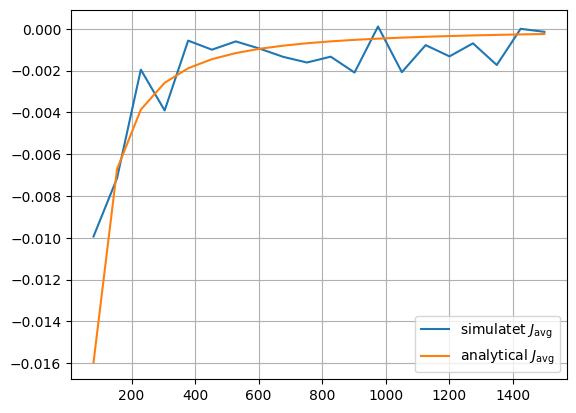

In [22]:

def oppgave_3_e(num_values = 20):
    """
        Initialiserer parameterene, Plotter gjennomsnitslig strømning per syklus mot T_p og det analytiske utrykket for gjennomsnitslig strømning sfa T_p
    """
    global N_x
    N_x = 10

    global periods
    periods = 20

    global N_points
    N_points = periods*N_x

    global N_particles
    N_particles = 40*N_x

    global alpha
    alpha = 0.8

    #initialiserer i potenial brønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x

    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)

    global T_p
    Tp_range = np.linspace(80, 1500, num_values, dtype=np.int16)

    #itererer over tidssteg lengder
    for i, T in enumerate(tqdm(Tp_range)):
        T_p = T
        particles = np.copy(particles_start)
        _, streams[i] = random_walk_cycle_vectorized(positions, particles)


    #plotter
    plt.plot(Tp_range, streams, label=r"simulatet $J_\text{avg}$") 
    plt.plot(Tp_range, analytical_avg_current(alpha, Tp_range), label=r"analytical $J_\text{avg}$")
    plt.legend()
    plt.grid()

    plt.show()

oppgave_3_e()

Sammenhengen mellom simulert og analytisk data plottet mot $T_p$ er relativt god. For de minste verdiene av $T_p$ ($ < \sim 100$)  er den simulerte strømmen mindre enn den analytiske. Utenfor dette intervallet er den simulerte strømmen større enn den analytiske. Det ser ut til å konvergere for større perioder for potensiale. Dette kan komme av at større perioder fører til at simulerigen får mer tid det partiklene står stille og dermed at strømningen synker. I tillegg er både analytisk og simulert strømning inversproposjonale med $T_p$. Hvilket gjør for at strømningen minker for større $T_p$.

#### f)
Det er tydelig at den analytiske løsningen bygger på et sett med antagelser. Som nevnt i d) er det liten grad av likhet mellom modellene når den termiske energien dominerer systemet. Dermed kan en anta at den analytiske løsningen bygger på en antagelse om at systemet eksisterer i grensen $k_b T \ll K$.

Videre antar den analytiske løsningen kontinuitet, dette ser vi fra formlen hvor det integreres over kontinuerlige sannsynlighetsfordelinger. Differansen som oppstår av dette, er liten og slår dessuten begge veier dermed har den lite å si for våre formål. Variasjonen kan minkes ved å kjøre simulasjonen med flere partikler. 

Det er også verdt og merke seg at utrykket for $J_\text{avg}$ er forskjellig for simulert og analytisk modell. Den analytiske modellen regner et skritt til høyre som én potenisalbrønn til høyre, mens simuleringen regner høyre skritt til å være et bindingspunkt til høyre.
Ettersom den slakere delen av potensialet er lengre enn den bratte vil simulerte proteiner ta flere steg mot bunnen av brønnen dersom de ender opp på den slake siden enn om de hadde endt opp på den bratte. Dermed blir det målte tallet for strømmen i det simulerte tilfellet større. For at disse skal bli likere kan man endre leddene som angir positiv og negativ strømning i analytisk løsning. For eksempel ved å vekte for antall steg vi forventer at en partikkel vil ta dersom den går til høyre eller venstre.